Saving job_market.csv to job_market.csv
Number of job postings: 250

Columns: ['job_title', 'company', 'location', 'job_type', 'category', 'salary_min', 'salary_max', 'experience_required', 'publication_date', 'skills', 'salary_mid']

Top 10 locations:
location
Austin, TX           27
Boston, MA           23
New York, NY         20
Denver, CO           20
Atlanta, GA          17
Chicago, IL          16
Toronto, Canada      16
Remote               16
San Francisco, CA    14
Seattle, WA          13
Name: count, dtype: int64

Top 10 job titles:
job_title
Machine Learning Engineer    14
Solutions Architect          13
Software Engineer            13
Technical Lead               13
Senior Software Engineer     12
Scooter Mechanic             11
Project Manager              10
Business Analyst             10
Frontend Developer            9
Product Manager               9
Name: count, dtype: int64


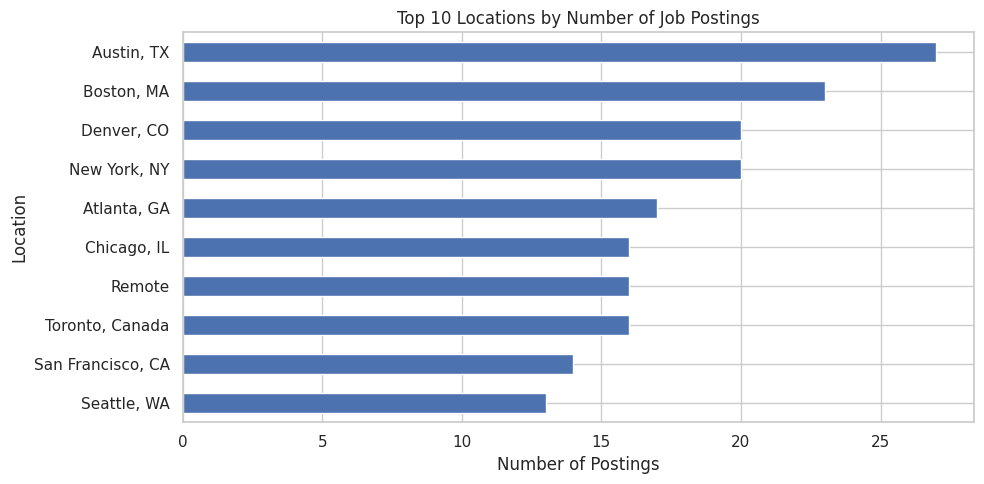


Summary of midpoint salary (salary_mid):
count       250.000000
mean     122376.662000
std       32730.888485
min       57500.000000
25%      103182.750000
50%      116681.750000
75%      147035.625000
max      221213.500000
Name: salary_mid, dtype: float64


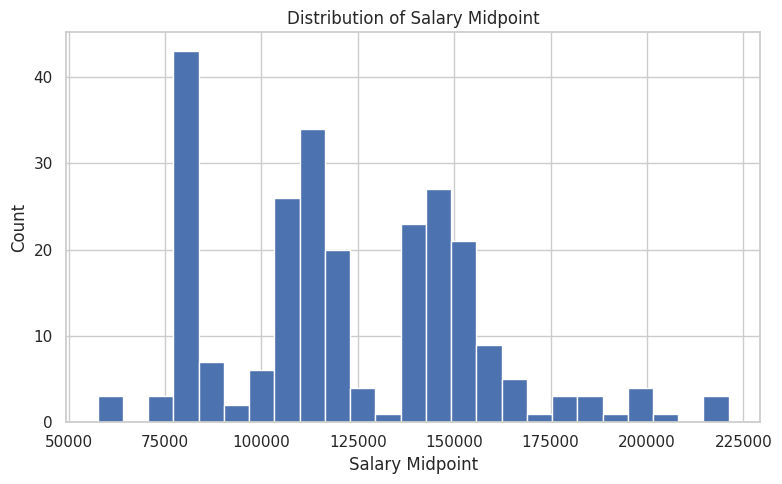


Summary of experience_required (years):
count    207.000000
mean       4.227053
std        2.461676
min        0.000000
25%        2.500000
50%        4.000000
75%        5.000000
max       12.000000
Name: experience_required, dtype: float64


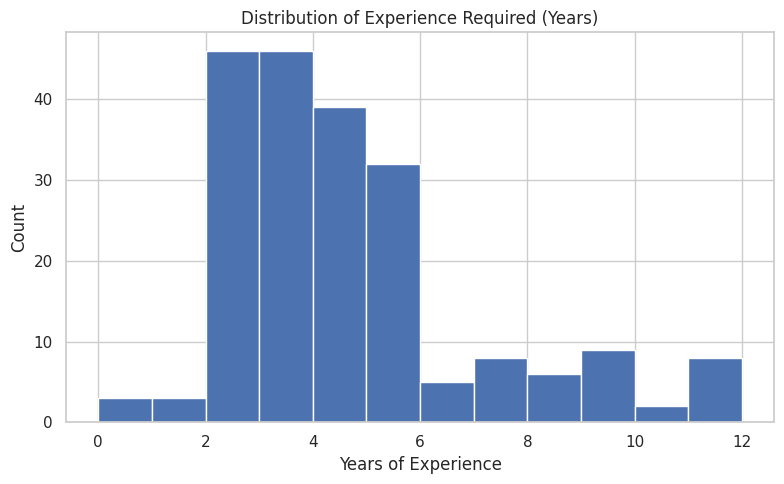

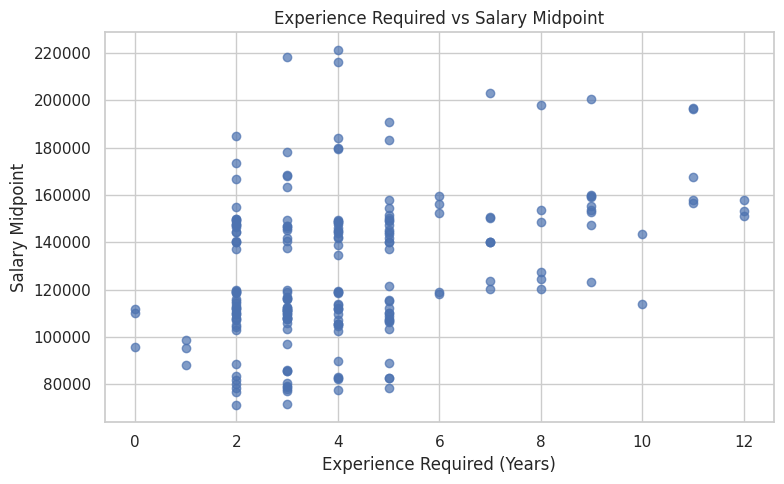


Correlation between experience_required and salary_mid: 0.389

Top 20 skills by frequency:
skills
machine learning    71
python              67
go                  60
git                 59
docker              58
agile               57
aws                 56
ci/cd               56
typescript          55
ruby                55
javascript          54
rest apis           53
node.js             52
react               52
sql                 51
kubernetes          48
java                47
tensorflow          43
mongodb             38
Name: count, dtype: int64


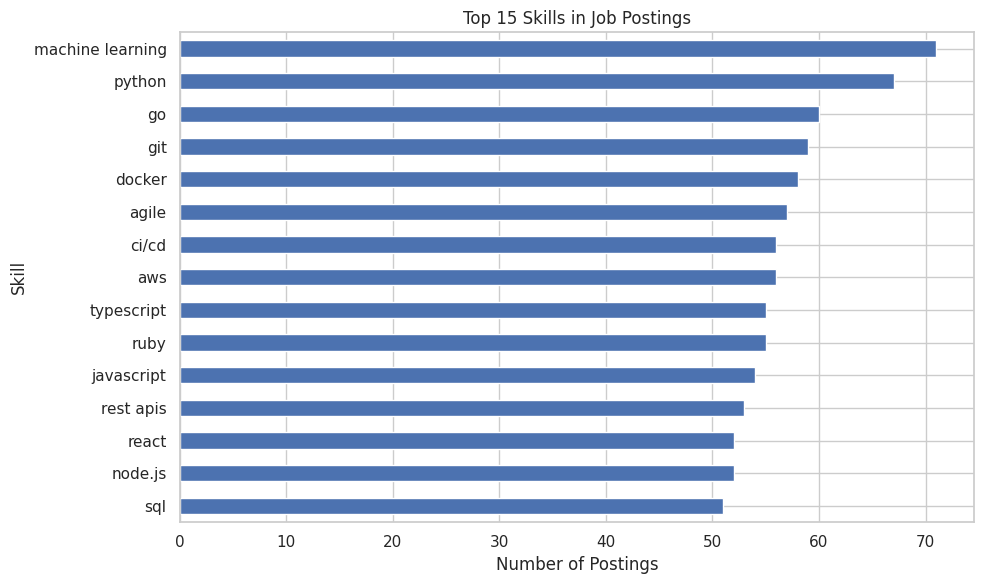


Top skills by median salary (min count = 20):
                  count     median           mean
skills                                           
java                 47  145041.50  136921.702128
aws                  56  141170.50  131531.821429
javascript           54  140303.25  131407.111111
machine learning     71  137165.50  130973.112676
sql                  51  120409.00  127454.098039
git                  59  119820.50  129429.508475
rest apis            53  119367.50  129289.839623
mongodb              38  119127.75  125636.855263
tensorflow           43  119061.50  124040.197674
node.js              52  119058.25  125817.153846


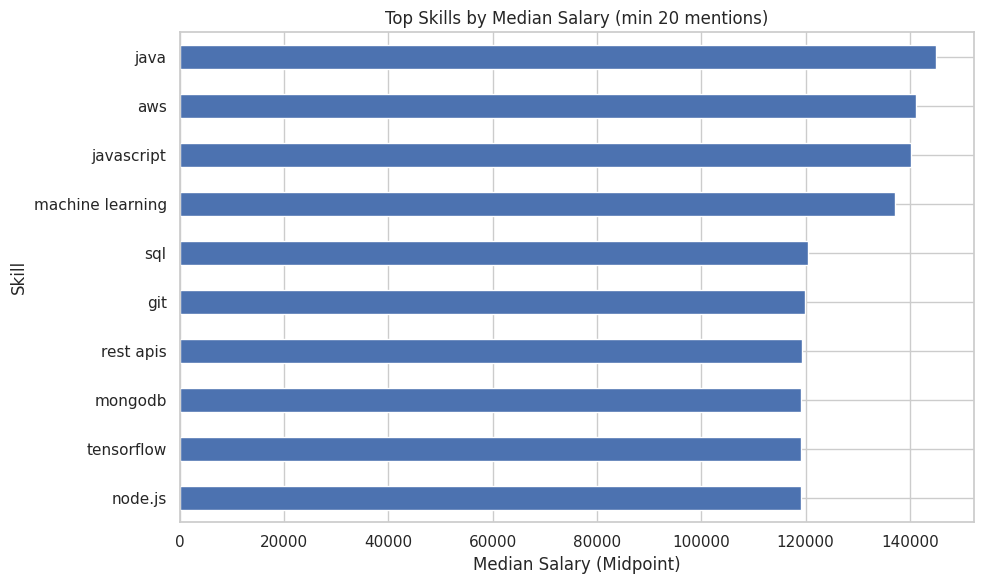


Cloud roles count: 56
Non-cloud roles count: 194
Median salary_mid (cloud roles): 141170.5
Median salary_mid (non-cloud roles): 115369.5
Median difference (cloud - non-cloud): 25801.0


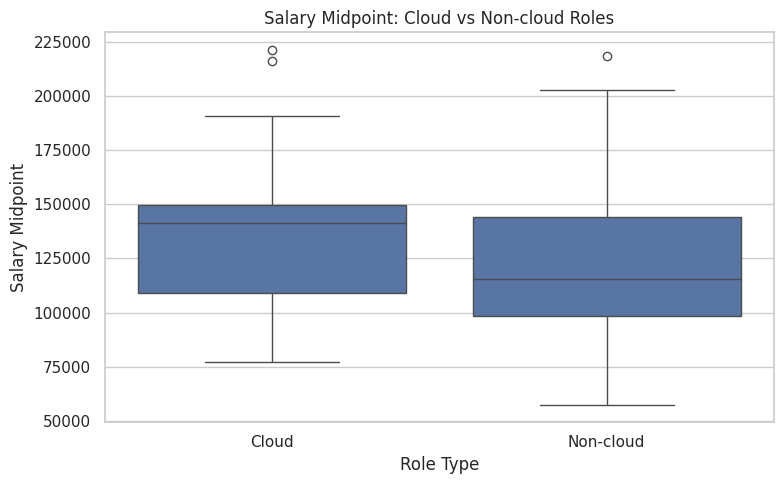


Correlation matrix:
                     salary_min  salary_max  salary_mid  experience_required
salary_min             1.000000    0.962669    0.984184             0.408596
salary_max             0.962669    1.000000    0.995395             0.371656
salary_mid             0.984184    0.995395    1.000000             0.389215
experience_required    0.408596    0.371656    0.389215             1.000000


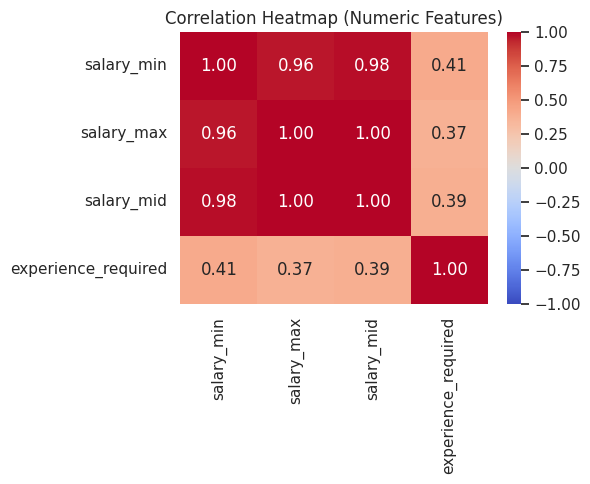


Postings per publication date:
publication_date
2025-11-27    200
dtype: int64


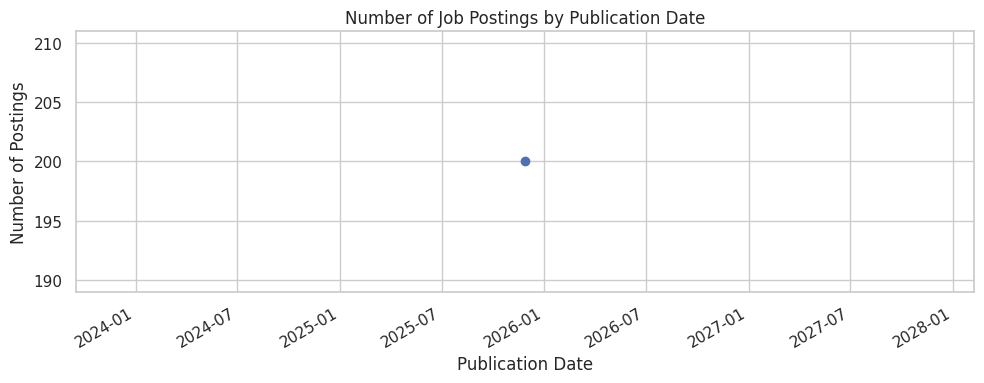

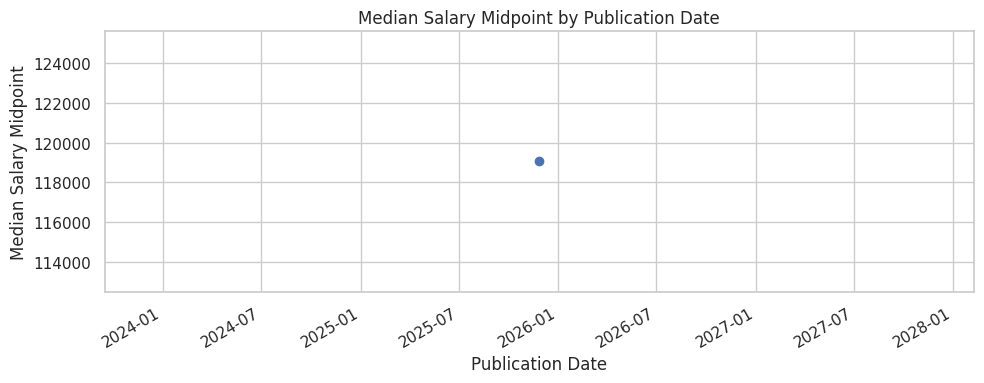

In [1]:
#Job market insight dataset storytelling
# This dataset provides a comprehensive view of job market opportunities, capturing key details about open positions across industries. It is designed for analysts, data scientists, and recruiters to explore trends in job roles, required skills, salaries, and experience levels. The dataset is ideal for tasks such as labor market analysis, skill gap identification, salary benchmarking, and predictive modeling of hiring trends.
#Target audience:  people looking for a job in this data engineering market
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Data source reference
# Kaggle dataset: Job Market Insight
# https://www.kaggle.com/datasets/shaistashahid/job-market-insight
# ------------------------------------------------------------

# Load the dataset (Colab: upload file manually when prompted)
from google.colab import files
import io

uploaded = files.upload()  # choose your CSV file (e.g., job_market.csv)

df = pd.read_csv(io.BytesIO(uploaded["job_market.csv"]))  # keep this name matching your uploaded file

# Basic cleaning and feature engineering
df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")
df["salary_mid"] = (df["salary_min"] + df["salary_max"]) / 2


# ------------------------------------------------------------
# 1. First look at the market
# ------------------------------------------------------------
#  Get a sense of how big this snapshot is and what kinds of jobs it contains.

print("Number of job postings:", len(df))
print("\nColumns:", df.columns.tolist())

print("\nTop 10 locations:")
print(df["location"].value_counts().head(10))

print("\nTop 10 job titles:")
print(df["job_title"].value_counts().head(10))

# Visual: Top hiring locations
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_locations.sort_values().plot(kind="barh")
plt.title("Top 10 Locations by Number of Job Postings")
plt.xlabel("Number of Postings")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Salary landscape
# ------------------------------------------------------------
# Story: What does pay look like in this snapshot? Are we in the 5-figure or 6-figure world?

print("\nSummary of midpoint salary (salary_mid):")
print(df["salary_mid"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["salary_mid"].dropna(), bins=25)
plt.title("Distribution of Salary Midpoint")
plt.xlabel("Salary Midpoint")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Experience requirements
# ------------------------------------------------------------
# Story: How many years of experience are employers asking for?

print("\nSummary of experience_required (years):")
print(df["experience_required"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["experience_required"].dropna(), bins=12)
plt.title("Distribution of Experience Required (Years)")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Relationship between experience and salary
# ------------------------------------------------------------
# Story: Does more experience generally line up with higher pay in this dataset?

exp_salary = df[["experience_required", "salary_mid"]].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(exp_salary["experience_required"], exp_salary["salary_mid"], alpha=0.7)
plt.title("Experience Required vs Salary Midpoint")
plt.xlabel("Experience Required (Years)")
plt.ylabel("Salary Midpoint")
plt.tight_layout()
plt.show()

corr_exp_salary = exp_salary.corr().loc["experience_required", "salary_mid"]
print("\nCorrelation between experience_required and salary_mid:", round(corr_exp_salary, 3))


# ------------------------------------------------------------
# 5. Skill frequency: what the market actually asks for
# ------------------------------------------------------------
# Story: Turn the skills column into a list and see what keeps showing up.

skills_series = df["skills"].dropna().astype(str).str.split(",")
all_skills = skills_series.explode().str.strip().str.lower()

skill_counts = all_skills.value_counts()
print("\nTop 20 skills by frequency:")
print(skill_counts.head(20))

top_n = 15
top_skills = skill_counts.head(top_n)

plt.figure(figsize=(10, 6))
top_skills.sort_values().plot(kind="barh")
plt.title(f"Top {top_n} Skills in Job Postings")
plt.xlabel("Number of Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Which skills seem to pay more?
# ------------------------------------------------------------
# Story: Not all skills are equal. Some are common, others also seem tied to higher salaries.

skills_exploded = (
    df[["salary_mid", "skills"]]
    .dropna(subset=["salary_mid", "skills"])
    .assign(skills=lambda d: d["skills"].str.split(","))
    .explode("skills")
)

skills_exploded["skills"] = skills_exploded["skills"].str.strip().str.lower()

skill_salary_stats = (
    skills_exploded
    .groupby("skills")["salary_mid"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

# Filter to skills that show up enough times to be meaningful
min_count = 20
skill_salary_filtered = skill_salary_stats[skill_salary_stats["count"] >= min_count]

print("\nTop skills by median salary (min count = 20):")
print(skill_salary_filtered.head(10))

top_paid_skills = skill_salary_filtered.head(10)

plt.figure(figsize=(10, 6))
top_paid_skills["median"].sort_values().plot(kind="barh")
plt.title("Top Skills by Median Salary (min 20 mentions)")
plt.xlabel("Median Salary (Midpoint)")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Hypothesis: Do cloud skills increase salary?
# ------------------------------------------------------------
# Hypothesis: roles that mention cloud skills (AWS / Azure / GCP / Cloud) pay more.

def has_cloud(skills_str):
    if not isinstance(skills_str, str):
        return False
    s = skills_str.lower()
    cloud_keywords = ["aws", "azure", "gcp", "google cloud", "cloud"]
    return any(kw in s for kw in cloud_keywords)

df["has_cloud_skill"] = df["skills"].apply(has_cloud)

cloud_roles = df[df["has_cloud_skill"] & df["salary_mid"].notna()]
noncloud_roles = df[~df["has_cloud_skill"] & df["salary_mid"].notna()]

cloud_median = cloud_roles["salary_mid"].median()
noncloud_median = noncloud_roles["salary_mid"].median()

print("\nCloud roles count:", len(cloud_roles))
print("Non-cloud roles count:", len(noncloud_roles))
print("Median salary_mid (cloud roles):", round(cloud_median, 2))
print("Median salary_mid (non-cloud roles):", round(noncloud_median, 2))
print("Median difference (cloud - non-cloud):", round(cloud_median - noncloud_median, 2))

comparison_df = pd.DataFrame({
    "salary_mid": pd.concat([cloud_roles["salary_mid"], noncloud_roles["salary_mid"]], ignore_index=True),
    "group": ["Cloud"] * len(cloud_roles) + ["Non-cloud"] * len(noncloud_roles)
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=comparison_df, x="group", y="salary_mid")
plt.title("Salary Midpoint: Cloud vs Non-cloud Roles")
plt.xlabel("Role Type")
plt.ylabel("Salary Midpoint")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Correlations among numeric features
# ------------------------------------------------------------
#  Look at how the numeric variables relate overall, not just pairwise.

numeric_cols = ["salary_min", "salary_max", "salary_mid", "experience_required"]
corr_matrix = df[numeric_cols].corr()

print("\nCorrelation matrix:")
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Time component
# ------------------------------------------------------------
#  Check if there is any variation by publication date,
# even though this dataset is essentially one snapshot in time.

date_df = df[df["publication_date"].notna()].copy()

if not date_df.empty:
    postings_per_date = date_df.groupby("publication_date").size()
    median_salary_per_date = date_df.groupby("publication_date")["salary_mid"].median()

    print("\nPostings per publication date:")
    print(postings_per_date)

    plt.figure(figsize=(10, 4))
    postings_per_date.plot(marker="o")
    plt.title("Number of Job Postings by Publication Date")
    plt.xlabel("Publication Date")
    plt.ylabel("Number of Postings")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    median_salary_per_date.plot(marker="o")
    plt.title("Median Salary Midpoint by Publication Date")
    plt.xlabel("Publication Date")
    plt.ylabel("Median Salary Midpoint")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo valid publication_date values for time-series analysis.")


The outcome shows that Austin under chart 1 shows that it has the highest number of job postings compared to other cities in Unites States therefore a higher likelihood of aquiring a job in this location.

The second chart shows the approxomite salary midpoint as a datascientist and the third and fourth charts is cross examining the estimation of experience required to gain which salary middpoint. So the outcome is to comprehend how many years of experience is required to potentially gain which salary midpoint.

the 5th chart determines which skills is more valuable within the job market to understand the likelihood of obtaining a job. As the chart displays the number of job postings is available based on which skill. So the outcome is to gain the most desirable skill to be most hireable(which has the highest job postings as the higher the job postings the more opportunity and likelihood of someone getting hired). As seen machine learning is the most desirable skill to make someone more likely to be hired.

Overall the outcome identifies the number of job postings based on skill in the job market and also the current median salary in the job market according to year/timestamp.